Using device: cuda
Epoch: 1 | Train Loss: 0.6896 | Val Loss: 0.6558 | Val Accuracy: 0.6192 | LR: 0.0002801
Epoch: 2 | Train Loss: 0.6667 | Val Loss: 0.6533 | Val Accuracy: 0.6183 | LR: 0.0007602
Epoch: 3 | Train Loss: 0.6641 | Val Loss: 0.6566 | Val Accuracy: 0.6152 | LR: 0.001
Epoch: 4 | Train Loss: 0.663 | Val Loss: 0.6514 | Val Accuracy: 0.6234 | LR: 0.0009504
Epoch: 5 | Train Loss: 0.66 | Val Loss: 0.6559 | Val Accuracy: 0.6237 | LR: 0.0008116
Epoch: 6 | Train Loss: 0.6576 | Val Loss: 0.6477 | Val Accuracy: 0.6268 | LR: 0.0006111
Epoch: 7 | Train Loss: 0.6556 | Val Loss: 0.6457 | Val Accuracy: 0.6268 | LR: 0.0003886
Epoch: 8 | Train Loss: 0.6539 | Val Loss: 0.6453 | Val Accuracy: 0.6272 | LR: 0.0001881
Epoch: 9 | Train Loss: 0.6529 | Val Loss: 0.645 | Val Accuracy: 0.6271 | LR: 4.94e-05
Epoch: 10 | Train Loss: 0.6522 | Val Loss: 0.6448 | Val Accuracy: 0.6259 | LR: 0.0


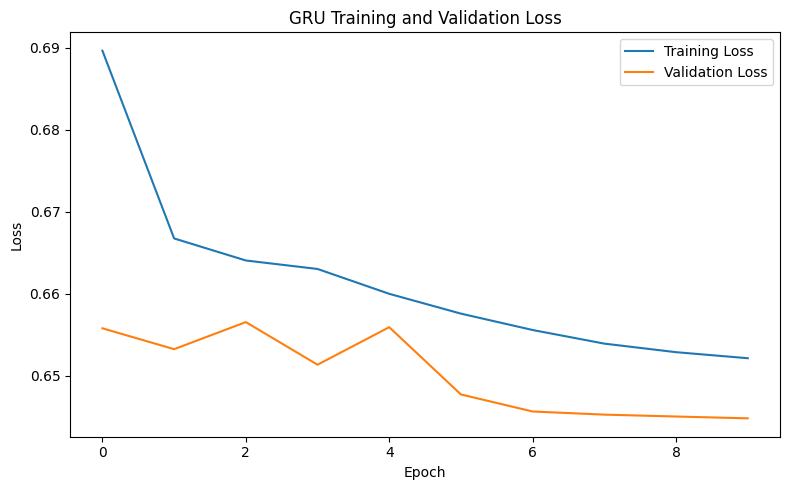

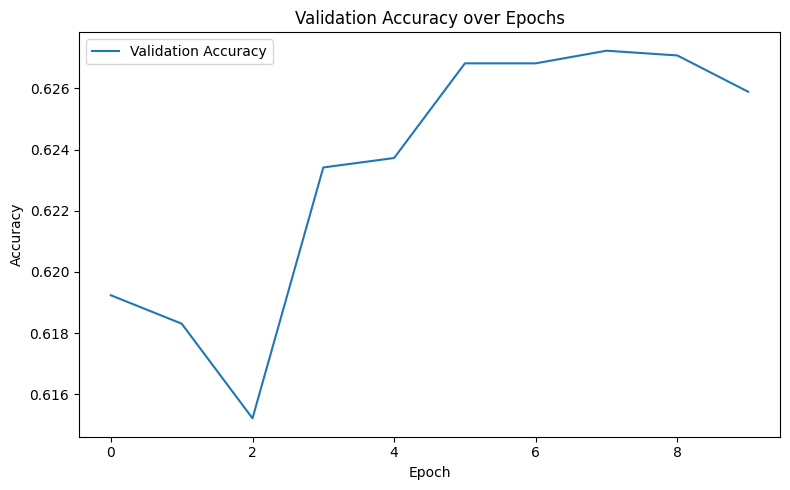

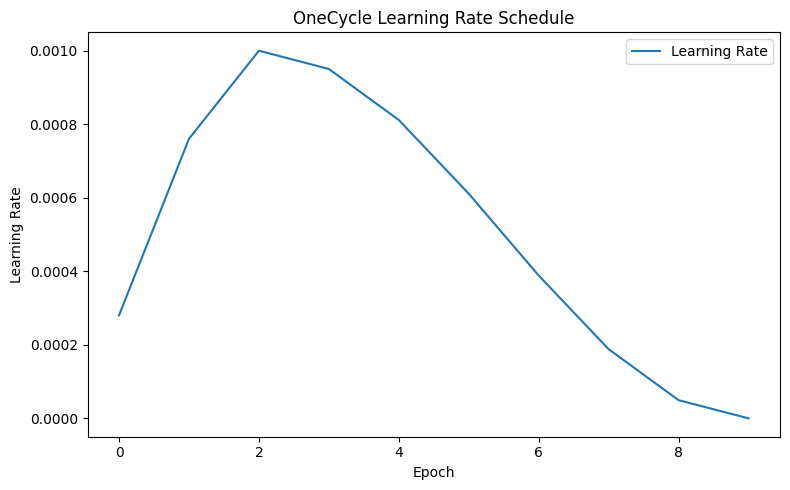


Final Validation Accuracy: 0.6259

              precision    recall  f1-score   support

           0       0.63      0.64      0.63      9847
           1       0.62      0.61      0.62      9551

    accuracy                           0.63     19398
   macro avg       0.63      0.63      0.63     19398
weighted avg       0.63      0.63      0.63     19398

Example Predictions:
Example 1 | Actual: Down | Predicted: Down
Example 2 | Actual: Up | Predicted: Up
Example 3 | Actual: Down | Predicted: Down
Example 4 | Actual: Up | Predicted: Up
Example 5 | Actual: Up | Predicted: Up
Example 6 | Actual: Down | Predicted: Up
Example 7 | Actual: Down | Predicted: Down
Example 8 | Actual: Down | Predicted: Down
Example 9 | Actual: Up | Predicted: Up
Example 10 | Actual: Down | Predicted: Down


In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


# Settings
INTERVAL_SECONDS = 10
EPOCHS = 10
BATCH_SIZE = 64


# Load data
train = pd.read_csv("train.csv")
train = train.dropna(subset=["target"])

train["label"] = (train["target"] > 0).astype(int)


# Group time intervals
def group_time_intervals(df, interval_seconds):
    df = df.copy()
    df["time_group"] = (df["seconds_in_bucket"] // interval_seconds) * interval_seconds

    grouped = df.groupby(
        ["stock_id", "date_id", "time_group"],
        as_index=False
    ).agg({
        "seconds_in_bucket": "last",
        "imbalance_size": "mean",
        "imbalance_buy_sell_flag": "last",
        "reference_price": "last",
        "matched_size": "mean",
        "far_price": "last",
        "near_price": "last",
        "bid_price": "last",
        "bid_size": "mean",
        "ask_price": "last",
        "ask_size": "mean",
        "wap": "last",
        "target": "last",
        "label": "last"
    })

    return grouped


train = group_time_intervals(train, INTERVAL_SECONDS)


# Basic features
train["bid_ask_spread"] = train["ask_price"] - train["bid_price"]
train["mid_price"] = (train["ask_price"] + train["bid_price"]) / 2
train["imbalance_ratio"] = train["imbalance_size"] / (train["matched_size"] + 1)
train["wap_reference_diff"] = train["wap"] - train["reference_price"]
train["wap_mid_diff"] = train["wap"] - train["mid_price"]
train["size_ratio"] = train["bid_size"] / (train["ask_size"] + 1)
train["matched_imbalance_ratio"] = train["matched_size"] / (train["imbalance_size"] + 1)


# Sequence-aware features
def add_sequence_features(df):
    df = df.sort_values(["stock_id", "date_id", "seconds_in_bucket"]).copy()
    grp = df.groupby(["stock_id", "date_id"])

    df["wap_lag1"] = grp["wap"].shift(1)
    df["wap_return"] = df["wap"] / (df["wap_lag1"].replace(0, np.nan) + 1e-8) - 1

    df["imbalance_roll3"] = grp["imbalance_ratio"].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )

    df["spread_roll3"] = grp["bid_ask_spread"].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )

    df["wap_roll_std"] = grp["wap"].transform(
        lambda x: x.rolling(5, min_periods=1).std()
    )

    return df.fillna(0)


train = add_sequence_features(train)


# Features
features = [
    "seconds_in_bucket",
    "imbalance_size",
    "imbalance_buy_sell_flag",
    "reference_price",
    "matched_size",
    "far_price",
    "near_price",
    "bid_price",
    "bid_size",
    "ask_price",
    "ask_size",
    "wap",
    "bid_ask_spread",
    "mid_price",
    "imbalance_ratio",
    "wap_reference_diff",
    "wap_mid_diff",
    "size_ratio",
    "matched_imbalance_ratio",
    "wap_return",
    "imbalance_roll3",
    "spread_roll3",
    "wap_roll_std",
]

train[features] = train[features].replace([np.inf, -np.inf], np.nan)
train[features] = train[features].fillna(0)


# Sequence length
if INTERVAL_SECONDS == 10:
    SEQ_LEN = 55
elif INTERVAL_SECONDS == 30:
    SEQ_LEN = 19
elif INTERVAL_SECONDS == 60:
    SEQ_LEN = 10
elif INTERVAL_SECONDS == 120:
    SEQ_LEN = 5
else:
    raise ValueError("Use 10, 30, 60, or 120 for INTERVAL_SECONDS.")


# Train / validation split before scaling
unique_dates = sorted(train["date_id"].unique())
split = int(0.8 * len(unique_dates))

train_dates = unique_dates[:split]
val_dates = unique_dates[split:]

train_df = train[train["date_id"].isin(train_dates)].copy()
val_df = train[train["date_id"].isin(val_dates)].copy()


# Scale using training data only
scaler = StandardScaler()
train_df[features] = scaler.fit_transform(train_df[features])
val_df[features] = scaler.transform(val_df[features])


# Dataset
class StockDataset(Dataset):
    def __init__(self, df):
        self.X = []
        self.y = []

        grouped = df.groupby(["stock_id", "date_id"])

        for _, g in grouped:
            g = g.sort_values("seconds_in_bucket")

            if len(g) == SEQ_LEN:
                self.X.append(g[features].values)
                self.y.append(g["label"].iloc[-1])

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = StockDataset(train_df)
val_dataset = StockDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# GRU model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 2)
        )

    def forward(self, x):
        _, hidden = self.gru(x)
        last_hidden = hidden[-1]
        return self.head(last_hidden)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = GRUModel(
    input_size=len(features),
    hidden_size=64,
    num_layers=2,
    dropout=0.3
).to(device)


# Loss, optimizer, scheduler
label_counts = train_df["label"].value_counts().sort_index()

class_weights = torch.tensor(
    [1.0 / label_counts[0], 1.0 / label_counts[1]],
    dtype=torch.float32
).to(device)

class_weights = class_weights / class_weights.sum()

loss_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.001,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy="cos"
)


# Training
train_losses = []
val_losses = []
val_accuracies = []
learning_rates = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = accuracy_score(all_labels, all_preds)
    current_lr = optimizer.param_groups[0]["lr"]

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    learning_rates.append(current_lr)

    print(
        "Epoch:", epoch + 1,
        "| Train Loss:", round(avg_train_loss, 4),
        "| Val Loss:", round(avg_val_loss, 4),
        "| Val Accuracy:", round(val_accuracy, 4),
        "| LR:", round(current_lr, 7)
    )


# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


# Plot validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.legend()
plt.tight_layout()
plt.show()


# Plot learning rate
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("OneCycle Learning Rate Schedule")
plt.legend()
plt.tight_layout()
plt.show()


# Final evaluation
print()
print("Final Validation Accuracy:", round(val_accuracies[-1], 4))
print()
print(classification_report(all_labels, all_preds))


# Example predictions
print("Example Predictions:")

for i in range(min(10, len(all_labels))):
    actual = "Up" if all_labels[i] == 1 else "Down"
    predicted = "Up" if all_preds[i] == 1 else "Down"

    print(
        "Example", i + 1,
        "| Actual:", actual,
        "| Predicted:", predicted
    )